                   title                                        description  \
0   Dick Johnson Is Dead  As her father nears the end of his life, filmm...   
1          Blood & Water  After crossing paths at a party, a Cape Town t...   
2              Ganglands  To protect his family from a powerful drug lor...   
3  Jailbirds New Orleans  Feuds, flirtations and toilet talk go down amo...   
4           Kota Factory  In a city of coaching centers known to train I...   

   Rating  
0       2  
1       2  
2       4  
3       1  
4       5  




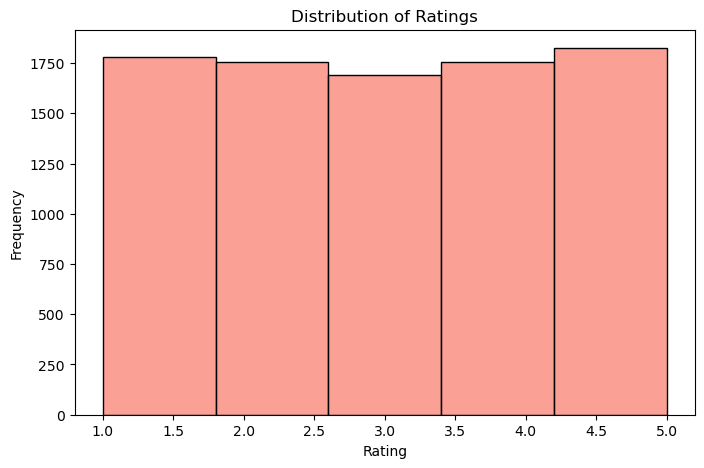


Count of each unique rating: 
Rating
5    1825
1    1778
2    1758
4    1755
3    1693
Name: count, dtype: int64




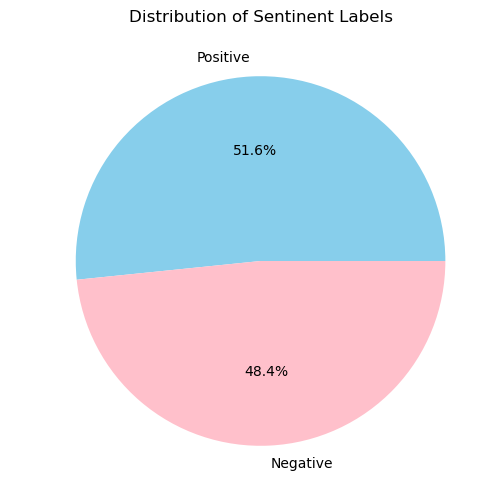

In [11]:
import pandas as pd
import seaborn as sns
from textblob import TextBlob
import matplotlib.pyplot as plt

#1. Data Loading
data = pd.read_csv("series_movies_descriptions.csv")
#dispaly first few rows
print(data.head())

#2. Exploratory Data Analysis
#histogram of the distributuon of the ratings
print("\n")
plt.figure(figsize = (8,5))
sns.histplot(data["Rating"], bins = 5, kde = False, color = "salmon", edgecolor = "black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.savefig("Distribution_of_ratings.png")
plt.show()

#display each unique rating
print("\nCount of each unique rating: ")
print(data["Rating"].value_counts())

#3. Sentiment Analysis
#function to compute the sentiment polarity
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

#create polarity dataframe
data["Polarity"] = data["description"].apply(get_sentiment)

#4.Classification of Sentinent
#classifying rach description either positive or negative
def classify_sentinent(polarity):
    return 'Positive' if polarity > 0 else 'Negative'

#add classification to dataframze as sentinent label
data["Sentinent Label"] = data["Polarity"].apply(classify_sentinent)

#5. Visualisations
#pie chart
print("\n")
sentinent_counts = data["Sentinent Label"].value_counts()
plt.figure(figsize = (6,6))
plt.pie(sentinent_counts, labels = sentinent_counts.index, autopct = "%1.1f%%", colors = ["skyblue", "pink"])
plt.title("Distribution of Sentinent Labels")
plt.ylabel(" ")
plt.savefig("sentinent_label_pie_chart.png")
plt.show()